In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('D:/HII/OneDrive/HydroDataSci/Project/เกณฑ์ฝน จ.สงขลา/Data')
OUTPUT_DIR = Path('D:/HII/rainfall_threshold_songkla/output')

# Data Loading

In [145]:
df_raw = pd.read_csv(
DATA_DIR / '20260410_Rainfall-สงขลา.csv',
    encoding='utf-8-sig',
    parse_dates=['rainfall_datetime'],
    dtype={'tele_station_oldcode': str}
)

In [146]:
df_r1h = pd.read_csv(
    DATA_DIR / '20260410_Rainfall1h-สงขลา.csv',
    encoding='utf-8-sig',
    parse_dates=['rainfall_datetime'],
    dtype={'tele_station_oldcode': str}
)

In [147]:
df_meta1 = pd.read_csv(
    DATA_DIR / 'm_tele_station_20220324.csv',
    encoding='utf-8-sig',
)

In [148]:
df_meta2 = pd.read_csv(
    DATA_DIR / 'm_tele_station_20260507.csv',
    encoding='utf-8-sig',
)

# General detail

In [149]:
df_raw.head()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
0,48568,สงขลา,2019-02-14 13:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
1,48568,สงขลา,2019-02-14 16:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
2,48568,สงขลา,2019-02-14 19:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
3,48568,สงขลา,2019-02-14 22:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD
4,48568,สงขลา,2019-02-15 01:00:00,NaN,NaN,NaN,NaN,0.0,บ่อยาง,เมืองสงขลา,สงขลา,ภาคใต้ฝั่งตะวันออก,TMD


In [150]:
df_r1h.head()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall1h,tumbon_name,amphoe_name,province_name
0,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 09:00:00,0.2,เขาแดง,สะบ้าย้อย,สงขลา
1,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 10:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
2,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 11:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
3,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 12:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา
4,FOP069,โรงเรียน ตชด.บ้านส้านักเอาะ,2023-02-18 13:00:00,0.0,เขาแดง,สะบ้าย้อย,สงขลา


In [151]:
df_meta1.head()

,id,subbasin_id,agency_id,geocode_id,tele_station_name_th,tele_station_name_en,tele_station_lat,tele_station_long,tele_station_oldcode,tele_station_type,...,critical_level_m,critical_level_msl,reference_id,subbasin_id_22,basin_id_22,subbasin_id_25,basin_id_25,river_gid,river_distant,adjust_geocode_id
0,1032662,106.0,12.0,1950.0,Rain เธเธธเธ•เธฐเนเธ,NaN,14.433429,101.87185,M_RAIN,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3538,148.0,8.0,2715.0,เธญ.เธ•เธฃเธฐเธเธฒเธฃเธเธทเธเธเธฅ,Trakan Phuet Phon,15.614920,105.01614,PMTS11,A,...,NaN,NaN,NaN,148.0,5.0,105.0,5.0,141708.0,0.007901,NaN
2,501187,234.0,3.0,6171.0,เธเนเธฒเธเธเนเธณเธเธงเธ,NaN,17.438261,100.67500,STN1149,R,...,NaN,NaN,NaN,234.0,9.0,161.0,9.0,82979.0,0.001031,NaN
3,651,209.0,9.0,6107.0,เธเธฅเธญเธเธเธฑเธเธเนเธณเธขเธก-เธเนเธฒ...,NaN,17.366200,99.84370,DIN001,A,...,NaN,NaN,NaN,209.0,8.0,147.0,8.0,84208.0,0.000043,NaN
4,1849,325.0,3.0,7313.0,เธเนเธฒเธเธชเธณเธเธฑเธเน€เธเธตเธขเธ,NaN,8.934702,99.70000,STN0066,R,...,NaN,NaN,NaN,325.0,22.0,220.0,21.0,216917.0,0.000739,NaN


In [152]:
df_meta2.head()

,tele_station_oldcode,tele_station_name,tele_station_lat,tele_station_long,tumbon_name,amphoe_name,province_name,agency_shortname,tele_station_type,tmd_area_name,basin_name,subbasin_name
0,0000,องค์การบริหารส่วนตำบลห้วยผา,19.426110,97.998340,หมอกจำแป่,เมืองแม่ฮ่องสอน,แม่ฮ่องสอน,DISASTER,R,ภาคเหนือ,สาละวิน,น้ำแม่ปายตอนล่างส่วนที่ 2
1,48300,แม่ฮ่องสอน,19.298972,97.975778,จองคำ,เมืองแม่ฮ่องสอน,แม่ฮ่องสอน,TMD,R,ภาคเหนือ,สาละวิน,น้ำแม่ปายตอนล่างส่วนที่ 2
2,48302,ดอยอ่างขาง,19.931389,99.048333,ม่อนปิ่น,ฝาง,เชียงใหม่,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่ฝาง
3,48303,เชียงราย,19.961389,99.881389,บ้านดู่,เมืองเชียงราย,เชียงราย,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่กกตอนล่างส่วนที่ 3
4,48304,เชียงราย สกษ.,19.870833,99.782778,ป่าอ้อดอนชัย,เมืองเชียงราย,เชียงราย,TMD,R,ภาคเหนือ,โขงเหนือ,น้ำแม่กกตอนล่างส่วนที่ 2


In [153]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8037169 entries, 0 to 8037168
Data columns (total 13 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tele_station_oldcode  str           
 1   station_name_th       str           
 2   rainfall_datetime     datetime64[us]
 3   rainfall10m           float64       
 4   rainfall5m            float64       
 5   rainfall30m           float64       
 6   rainfall1h            float64       
 7   rainfall3h            float64       
 8   tumbon_name           str           
 9   amphoe_name           str           
 10  province_name         str           
 11  tmd_area_name         str           
 12  agency                str           
dtypes: datetime64[us](1), float64(5), str(7)
memory usage: 797.1 MB


In [154]:
df_r1h.info()

<class 'pandas.DataFrame'>
RangeIndex: 889283 entries, 0 to 889282
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tele_station_oldcode  889283 non-null  str           
 1   station_name_th       889283 non-null  str           
 2   rainfall_datetime     889283 non-null  datetime64[us]
 3   rainfall1h            889283 non-null  float64       
 4   tumbon_name           889283 non-null  str           
 5   amphoe_name           889283 non-null  str           
 6   province_name         889283 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 47.5 MB


In [155]:
df_meta1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6499 entries, 0 to 6498
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     6499 non-null   int64  
 1   subbasin_id            6475 non-null   float64
 2   agency_id              6492 non-null   float64
 3   geocode_id             6061 non-null   float64
 4   tele_station_name_th   6027 non-null   str    
 5   tele_station_name_en   2277 non-null   str    
 6   tele_station_lat       6379 non-null   float64
 7   tele_station_long      6374 non-null   float64
 8   tele_station_oldcode   6493 non-null   str    
 9   tele_station_type      5065 non-null   str    
 10  left_bank              1316 non-null   float64
 11  right_bank             1319 non-null   float64
 12  ground_level           1211 non-null   float64
 13  water_storage_station  0 non-null      float64
 14  max_waterlevel_20y     0 non-null      float64
 15  sort_order     

In [156]:
df_meta2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5722 entries, 0 to 5721
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tele_station_oldcode  5722 non-null   str    
 1   tele_station_name     5721 non-null   str    
 2   tele_station_lat      5722 non-null   float64
 3   tele_station_long     5722 non-null   float64
 4   tumbon_name           5705 non-null   str    
 5   amphoe_name           5707 non-null   str    
 6   province_name         5710 non-null   str    
 7   agency_shortname      5722 non-null   str    
 8   tele_station_type     5721 non-null   str    
 9   tmd_area_name         5710 non-null   str    
 10  basin_name            5718 non-null   str    
 11  subbasin_name         5718 non-null   str    
dtypes: float64(2), str(10)
memory usage: 536.6 KB


# Data Cleaning 

clean 'df'

In [157]:
rain_cols = ['rainfall10m', 'rainfall5m', 'rainfall30m', 'rainfall1h', 'rainfall3h']

df_no_sentinel = df_raw.replace(999999.0, np.nan)

phantom_rows = df_no_sentinel.loc[:, rain_cols].isna().all(axis=1)

df = df_no_sentinel[~phantom_rows]

df

print(f'Total number of phantom rows dropped: {phantom_rows.sum()} ({round(phantom_rows.sum()/len(df) * 100, 2)}%)')
print(f'Number of stations (raw): {df_raw['tele_station_oldcode'].nunique()}')
print(f'Number of stations (after dropping NaN): {df['tele_station_oldcode'].nunique()}')
print(f'Shape of df (cleaned): {df.shape}')

Total number of phantom rows dropped: 4671761 (138.82%)
Number of stations (raw): 99
Number of stations (after dropping NaN): 42
Shape of df (cleaned): (3365408, 13)


In [158]:
df.tail()

,tele_station_oldcode,station_name_th,rainfall_datetime,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h,tumbon_name,amphoe_name,province_name,tmd_area_name,agency
8022679,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 04:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022680,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 05:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022681,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 06:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022682,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 07:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII
8022683,VLGE10,ชุมชนบ้านเขาพระ,2017-04-18 08:00:00,0.0,NaN,NaN,0.0,NaN,เขาพระ,รัตภูมิ,สงขลา,ภาคใต้ฝั่งตะวันออก,HII


# Number of stations

In [159]:
stn_in_df = set(df['tele_station_oldcode'])
stn_in_df_r1h = set(df_r1h['tele_station_oldcode'])
stn_intersected = stn_in_df.intersection(stn_in_df_r1h)
stn_songkla = set.union(stn_in_df, stn_in_df_r1h)     # Same as: stn_songkla = stn_in_df | stn_in_df_r1h

stn_meta1 = set(df_meta1['tele_station_oldcode'])
stn_not_in_meta1 = stn_songkla - stn_meta1
stn_in_meta1 = stn_meta1.intersection(stn_songkla)

stn_meta2 = set(df_meta2['tele_station_oldcode'])
stn_not_in_meta2 = stn_songkla - stn_meta2
stn_in_meta2 = stn_meta2.intersection(stn_songkla)


In [160]:
print(f'=== Number of stations ===\n')

print(f'• Total unique stations (df and df_r1 combined): {len(stn_songkla)}')
print(f'• Stations in df_r1h: {len(stn_in_df_r1h)}')
print(f'• Stations in df: {len(stn_in_df)}')
print(f'• Intersected stations: {len(stn_intersected)} \n')

print(f'• Songkla stations (in metadata1): {len(stn_in_meta1)}')
print(f'• Songkla stations (not in metadata1): {len(stn_not_in_meta1)} \n')

print(f'• Songkla: {len(stn_songkla)}')
print(f'• Songkla stations (in metadata2): {len(stn_in_meta2)}')
print(f'• Songkla stations (not in metadata2): {len(stn_not_in_meta2)} \n')

=== Number of stations ===

• Total unique stations (df and df_r1 combined): 134
• Stations in df_r1h: 114
• Stations in df: 42
• Intersected stations: 22 

• Songkla stations (in metadata1): 91
• Songkla stations (not in metadata1): 43 

• Songkla: 134
• Songkla stations (in metadata2): 102
• Songkla stations (not in metadata2): 32 



Some stations might not exist in both df_meta1 and df_meta2 (basically they has no lat/long). So, let's check it.

In [161]:
stn_orphans = stn_songkla - stn_meta1 - stn_meta2
print(f'Number of stations not in metadata1 and metadata2: {len(stn_orphans)}')
print(stn_orphans)

Number of stations not in metadata1 and metadata2: 1
{'TH28'}


In [162]:
df_meta1_stn_latlong = df_meta1[['tele_station_oldcode', 'tele_station_lat', 'tele_station_long']]

df_meta1_stn_latlong[
    df_meta1_stn_latlong['tele_station_lat'].isnull() &              # filter by condition #1
    df_meta1_stn_latlong['tele_station_oldcode'].isin(stn_songkla)       # chain another condition #2
]

,tele_station_oldcode,tele_station_lat,tele_station_long


In [163]:
df_meta2_stn_latlong = df_meta2[['tele_station_oldcode', 'tele_station_lat', 'tele_station_long']]

df_meta2_stn_latlong[
    df_meta2_stn_latlong['tele_station_lat'].isnull() &              # filter by condition #1
    df_meta2_stn_latlong['tele_station_oldcode'].isin(stn_songkla)       # chain another condition #2
]

,tele_station_oldcode,tele_station_lat,tele_station_long


# Monthly Completeness of telestations

### Monthly Completness (df_r1h)

  The steps are:
  1. Extract year-month from datetime
  2. Count actual records per station per month
  3. Build a complete index of all station+month combinations (so missing months show as 0, not blank)
  4. Calculate expected records per month (hours in that month)
  5. Divide actual/expected → completeness %
  6. Pivot to wide format → heatmap

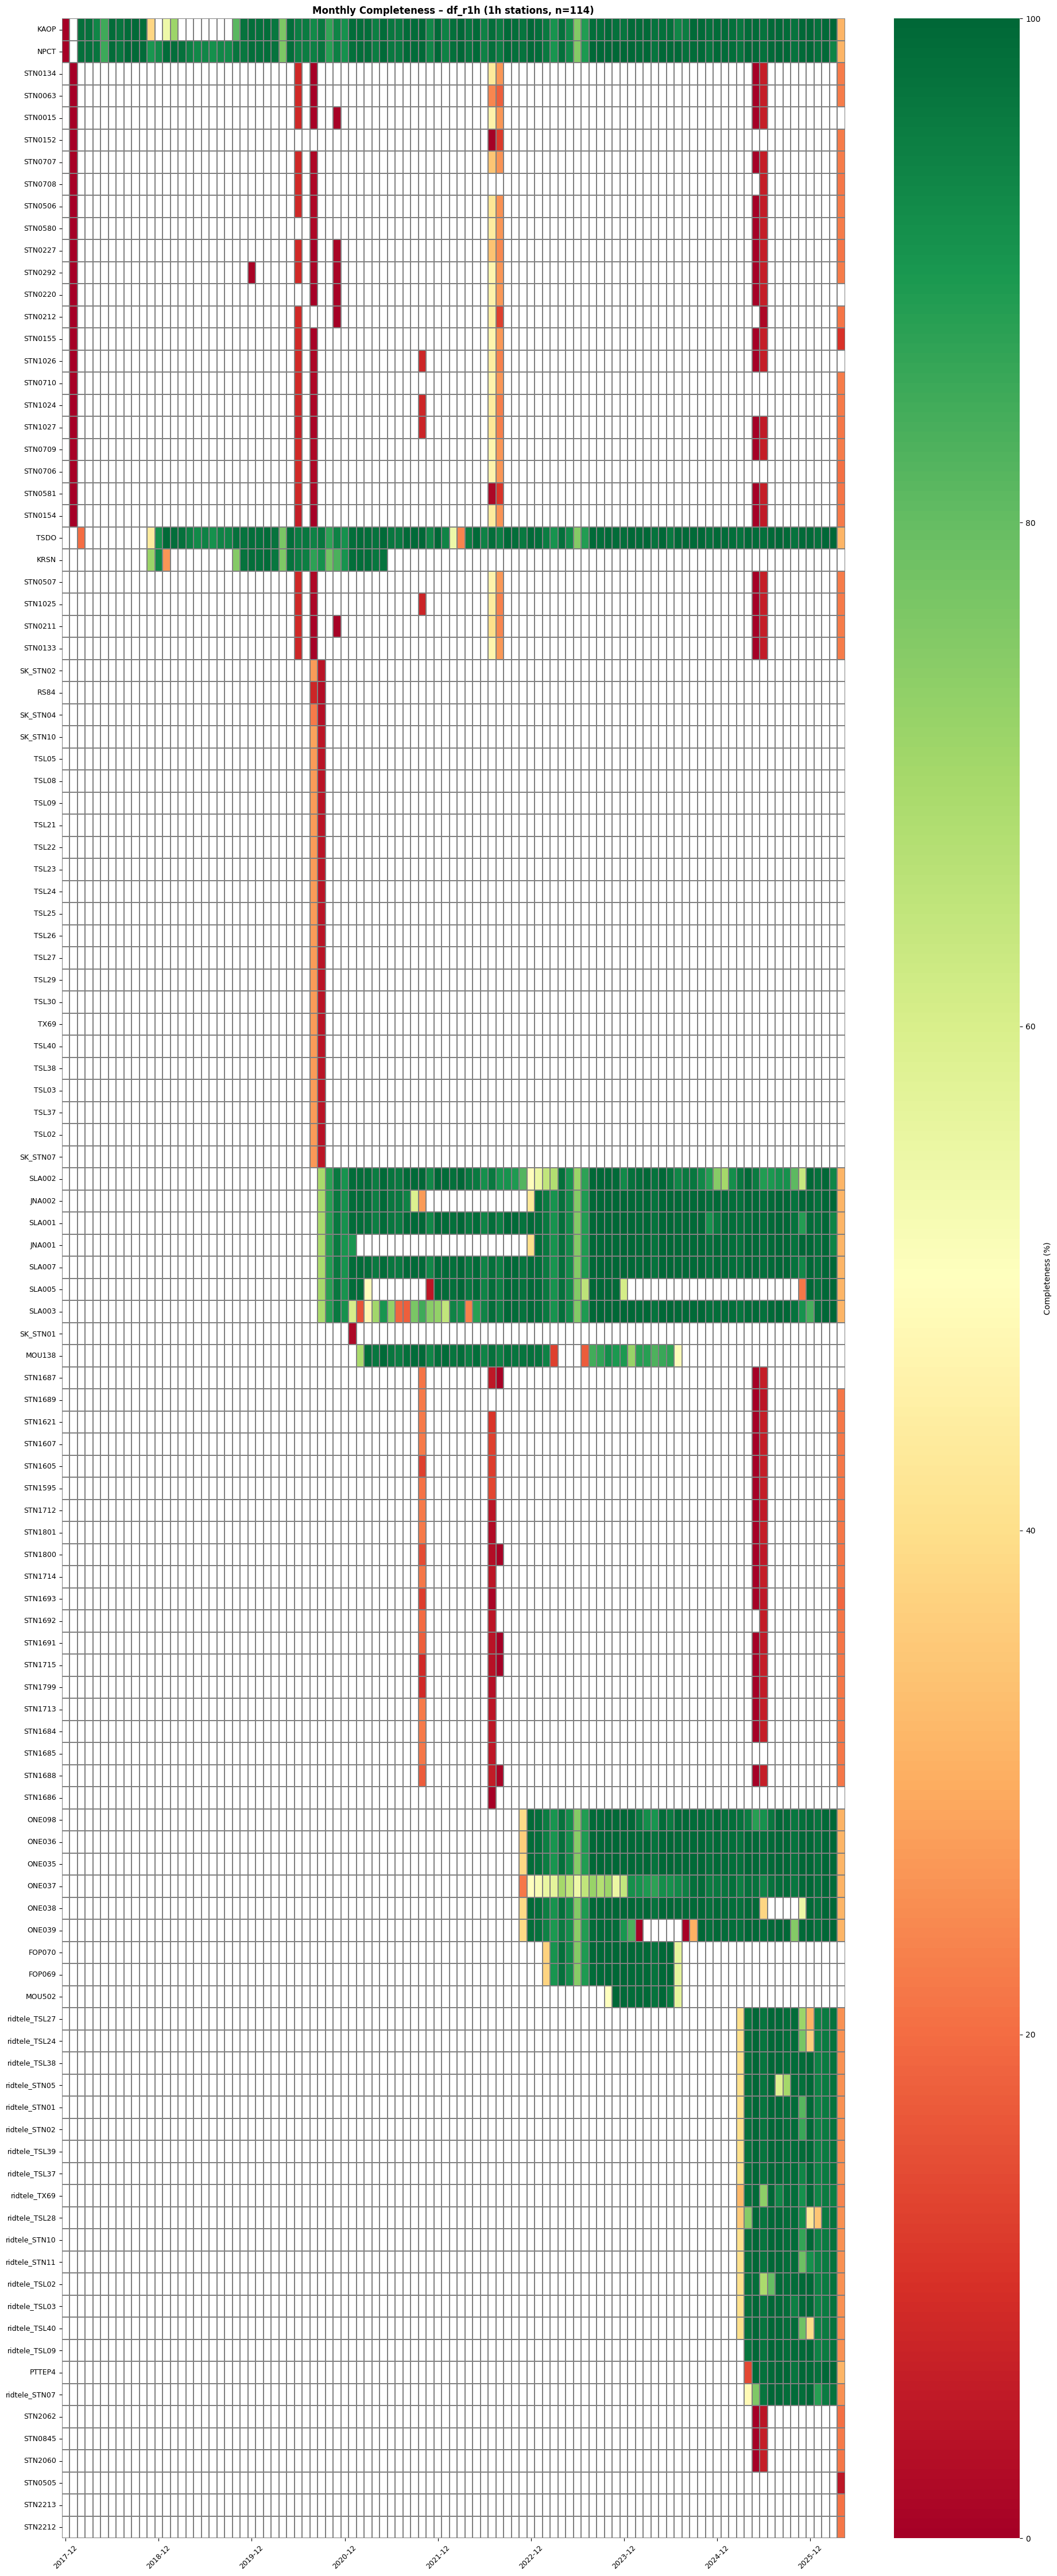

In [164]:
df_r1h['year_month'] = df_r1h['rainfall_datetime'].dt.to_period('M')
r1h_monthly = df_r1h.groupby(['tele_station_oldcode', 'year_month']).size()

r1h_period_idx = pd.period_range(
    start=df_r1h['rainfall_datetime'].min(),
    end=df_r1h['rainfall_datetime'].max(),
    freq='M'
)

r1h_full_idx = pd.MultiIndex.from_product([stn_in_df_r1h, r1h_period_idx], names=['station', 'year_month'])
r1h_monthly = r1h_monthly.reindex(r1h_full_idx, fill_value=np.nan)

r1h_expected = r1h_full_idx.get_level_values('year_month').days_in_month * 24
r1h_completeness = (r1h_monthly / r1h_expected) * 100
r1h_pivot = r1h_completeness.unstack('year_month')

r1h_first_rec = r1h_pivot.apply(lambda x: x.first_valid_index(), axis=1)
r1h_pivot = r1h_pivot.loc[r1h_first_rec.sort_values().index]

r1h_n = len(r1h_pivot)
fig_height = max(6, r1h_n * 0.5)
fig, ax = plt.subplots(figsize=(22, fig_height))
sns.heatmap(data=r1h_pivot, ax=ax,
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, linecolor='gray',
            cbar_kws={'label': 'Completeness (%)'},
            xticklabels=12)
ax.set_title(f'Monthly Completeness – df_r1h (1h stations, n={r1h_n})',
            fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9, rotation=45)
plt.show()

In [165]:
df.isna().sum()

tele_station_oldcode          0
station_name_th               0
rainfall_datetime             0
rainfall10m              305127
rainfall5m              3365408
rainfall30m             3365408
rainfall1h               266752
rainfall3h              3098660
tumbon_name                   0
amphoe_name                   0
province_name                 0
tmd_area_name                 0
agency                        0
dtype: int64

do all stations fall cleanly into exactly one group

In [166]:
df_grouped_resolution = df.groupby('tele_station_oldcode')[['rainfall10m', 'rainfall5m', 'rainfall30m', 'rainfall1h', 'rainfall3h']].count()
df_grouped_resolution

,rainfall10m,rainfall5m,rainfall30m,rainfall1h,rainfall3h
tele_station_oldcode,,,,,
48568,0,0,0,0,17616
48569,0,0,0,0,17628
48571,0,0,0,0,17565
48574,0,0,0,0,17580
568501,0,0,0,0,3263
568502,0,0,0,0,3257
9999911,0,0,0,0,3220
EL06,0,0,0,0,14276
EL07,0,0,0,0,19925


Some station has values more than 1 resolutions.

For example 'FOP069' station has rainfall values in 'rainfall10m' and 'rainfall1h' columns.

However, it actually is a 1h-resolution station after inspecting its 'rainfall_datetime' column.

## Monthly Completness (df)

### Determine a resolution of each station in df

In [167]:
df['interval'] = df.groupby('tele_station_oldcode')['rainfall_datetime'].diff().dt.total_seconds() / 60

interval_count = df.groupby(['tele_station_oldcode', 'interval']).size()

df_resolution = interval_count.groupby(level=0).idxmax().str[1].to_frame(name='interval')

total_count = interval_count.groupby('tele_station_oldcode').sum()

df_resolution['dominant_pct'] = round((interval_count.groupby(level=0).max() / total_count) * 100, 2)

df_resolution.index.name = 'station'

df_resolution

,interval,dominant_pct
station,,
48568,180.0,87.81
48569,180.0,87.90
48571,180.0,87.72
48574,180.0,87.78
568501,180.0,89.09
568502,180.0,88.88
9999911,180.0,88.10
EL06,60.0,89.30
EL07,60.0,94.22


In [168]:
df_resolution['dominant_pct'].min()

np.float64(45.86)

In [169]:
df_resolution.sort_values(by=['dominant_pct'], ascending=False, inplace=True)
print(df_resolution)

         interval  dominant_pct
station                        
ONE038       10.0         99.50
ONE036       10.0         99.43
PTTEP4       10.0         99.43
ONE035       10.0         99.39
SLA005       10.0         99.15
ONE039       10.0         98.98
SLA001       10.0         98.40
SLA007       10.0         97.83
JNA001       10.0         96.98
JNA002       10.0         96.74
SLA002       10.0         96.59
SLA003       10.0         96.45
TH27         60.0         94.69
EL07         60.0         94.22
TF50         60.0         93.28
TF52         60.0         93.04
TF45         60.0         92.80
ONE037       10.0         89.77
EL06         60.0         89.30
568501      180.0         89.09
568502      180.0         88.88
9999911     180.0         88.10
48569       180.0         87.90
48568       180.0         87.81
48574       180.0         87.78
48571       180.0         87.72
TF53         60.0         81.28
TH26         60.0         80.78
TF43         60.0         79.60
TSDO    

### Filter out station with less than 70% of dominant_pct

AS theirdata are not consistent enough to determine a resolution

In [170]:
df_resolution_filtered = df_resolution[df_resolution['dominant_pct'] >= 70]
df_stn_great = df_resolution_filtered.index.tolist()

In [187]:
interval_filter = df_resolution_filtered['interval'] == 10

interval_filter.index.to_list()

['ONE038',
 'ONE036',
 'PTTEP4',
 'ONE035',
 'SLA005',
 'ONE039',
 'SLA001',
 'SLA007',
 'JNA001',
 'JNA002',
 'SLA002',
 'SLA003',
 'TH27',
 'EL07',
 'TF50',
 'TF52',
 'TF45',
 'ONE037',
 'EL06',
 '568501',
 '568502',
 '9999911',
 '48569',
 '48568',
 '48574',
 '48571',
 'TF53',
 'TH26',
 'TF43',
 'TSDO',
 'TF49',
 'KAOP',
 'VLGE10',
 'NPCT',
 'TH28',
 'FOP070',
 'TF40',
 'ONE098',
 'KRSN',
 'FOP069']

In [194]:
x = df[df['tele_station_oldcode'].isin(interval_filter.index.to_list())]

In [195]:
x['tele_station_oldcode'].nunique()

40

Two station were dropped before plotting heatmaps

Number of stations for 10.0 interval: 13
Number of stations for 60.0 interval: 20
Number of stations for 180.0 interval: 7


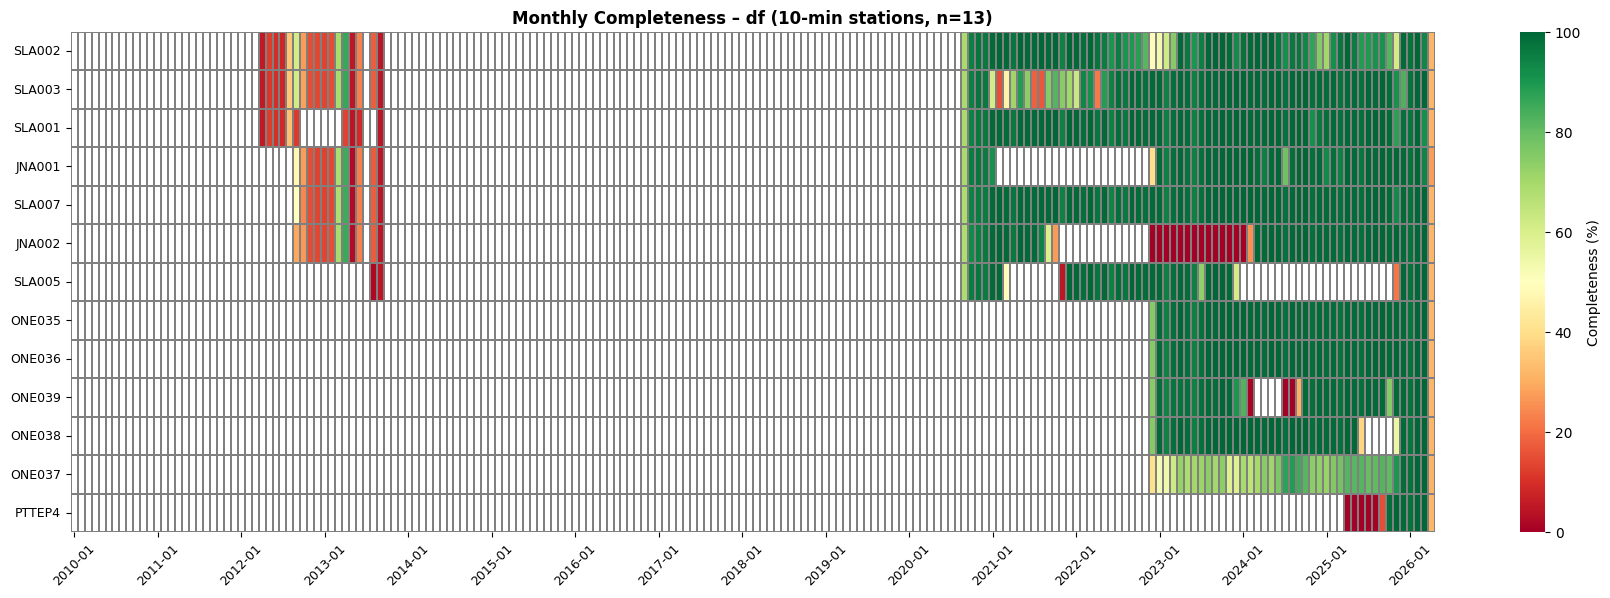

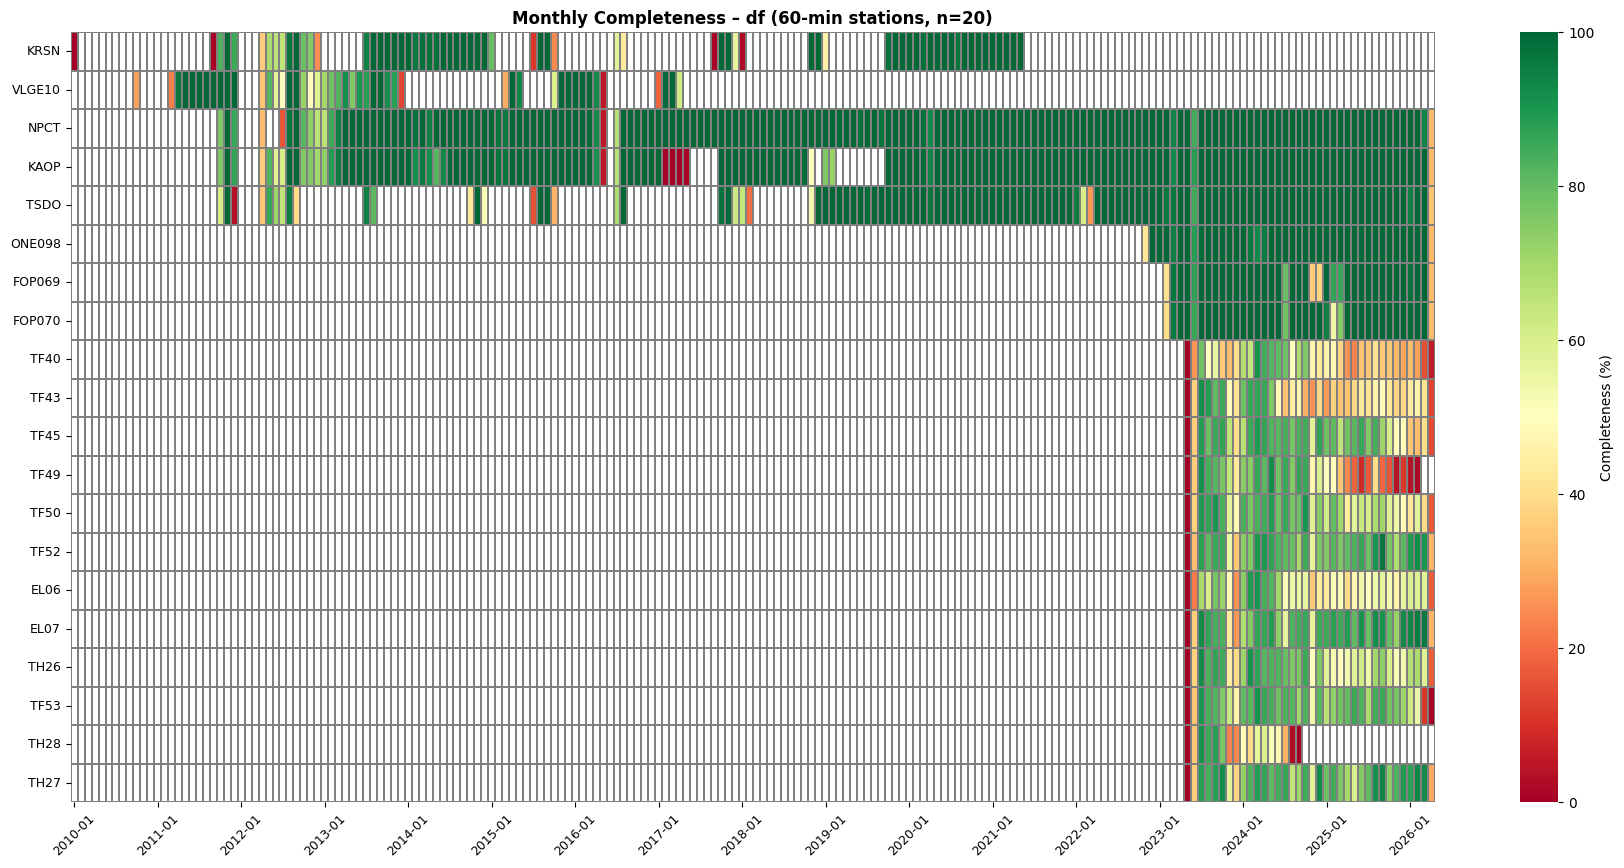

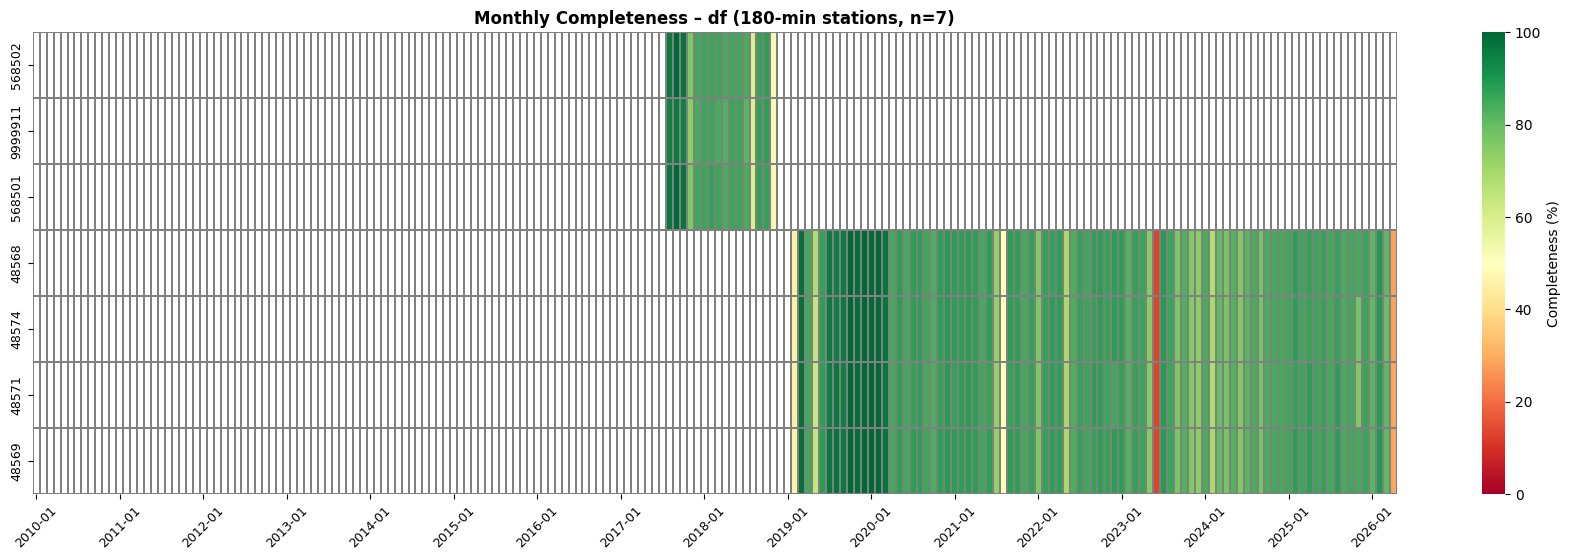

In [ ]:
pivot_list = []

for interval in df_resolution_filtered['interval'].unique(): 
    
    interval_filter = df_resolution_filtered['interval'] == interval

    cadence = df[df['tele_station_oldcode'].isin(interval_filter.index[interval_filter].to_list())]
    
    print(f'Number of stations for {interval} interval: {cadence['tele_station_oldcode'].nunique()}')
    
    cadence['year_month'] = cadence['rainfall_datetime'].dt.to_period('M')
    monthly = cadence.groupby(['tele_station_oldcode', 'year_month']).size()

    period_idx = pd.period_range(
        start=df['rainfall_datetime'].min(),
        end=df['rainfall_datetime'].max(),
        freq='M'
    )

    stns = cadence['tele_station_oldcode'].unique()
    full_idx = pd.MultiIndex.from_product([stns, period_idx], names=['station', 'year_month'])
    monthly = monthly.reindex(full_idx, fill_value=np.nan)

    expected = full_idx.get_level_values('year_month').days_in_month * 24 * (60 / interval)
    completeness = (monthly / expected) * 100
    pivot = completeness.unstack('year_month')

    first_rec = pivot.apply(lambda x: x.first_valid_index(), axis=1)
    pivot = pivot.loc[first_rec.sort_values().index]
    
    pivot_list.append(pivot)
    
    n = len(pivot)
    fig_height = max(6, n * 0.5)
    fig, ax = plt.subplots(figsize=(22, fig_height))
    sns.heatmap(data=pivot, ax=ax,
                cmap='RdYlGn', vmin=0, vmax=100,
                linewidths=0.3, linecolor='gray',
                cbar_kws={'label': 'Completeness (%)'},
                xticklabels=12)
    ax.set_title(f'Monthly Completeness – df ({int(interval)}-min stations, n={n})',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    plt.show()


In [175]:
combined_df_pivot = pd.concat(pivot_list, axis=0)

In [176]:
len(combined_df_pivot)

109

In [177]:
df_r1h.info()

<class 'pandas.DataFrame'>
RangeIndex: 889283 entries, 0 to 889282
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tele_station_oldcode  889283 non-null  str           
 1   station_name_th       889283 non-null  str           
 2   rainfall_datetime     889283 non-null  datetime64[us]
 3   rainfall1h            889283 non-null  float64       
 4   tumbon_name           889283 non-null  str           
 5   amphoe_name           889283 non-null  str           
 6   province_name         889283 non-null  str           
 7   year_month            889283 non-null  period[M]     
dtypes: datetime64[us](1), float64(1), period[M](1), str(5)
memory usage: 54.3 MB


### Summary DataFrame of df_r1h

In [178]:
r1h_summary = df_r1h.groupby('tele_station_oldcode')['rainfall_datetime'].agg(['min', 'max'])
r1h_summary['span_yr'] = r1h_summary['max'] - r1h_summary['min']
r1h_summary['span_yr'] = r1h_summary['span_yr'] / pd.Timedelta(365.25, 'D')
r1h_summary.rename(columns={'min': 'start_date','max': 'lastest_date'}, inplace=True)
r1h_summary['lifetime_pct'] = r1h_pivot.mean(axis=1)

r1h_summary

,start_date,lastest_date,span_yr,lifetime_pct
tele_station_oldcode,,,,
FOP069,2023-02-18 09:00:00,2024-07-18 12:00:00,1.413073,90.719998
FOP070,2023-02-18 14:00:00,2024-07-18 12:00:00,1.412503,90.847311
JNA001,2020-09-09 16:00:00,2026-04-10 09:00:00,5.581679,93.850620
JNA002,2020-09-09 16:00:00,2026-04-10 09:00:00,5.581679,92.788625
KAOP,2017-12-31 23:00:00,2026-04-10 09:00:00,8.272188,93.455924
...,...,...,...,...
ridtele_TSL37,2025-03-18 14:00:00,2026-04-10 08:00:00,1.061602,88.470302
ridtele_TSL38,2025-03-18 14:00:00,2026-04-10 08:00:00,1.061602,88.867127
ridtele_TSL39,2025-03-18 14:00:00,2026-04-10 08:00:00,1.061602,88.867127


# Filtering for reliable stations

In [179]:
r1h_after_completeness = r1h_summary[(r1h_summary['lifetime_pct'] >= 70)]
r1h_after_span = r1h_after_completeness[((r1h_after_completeness['span_yr'] >= 3))]
r1h_qualified = r1h_after_span[r1h_after_span.index.isin(df_meta2['tele_station_oldcode'])]

In [180]:
r1h_labels = ['has lag/long', 'span >= 3 year', 'lifetime compleness >= 70%', 'Station in raw data']

r1h_counts = [len(r1h_qualified),
          len(r1h_after_span),
          len(r1h_after_completeness),
          df_r1h['tele_station_oldcode'].nunique()]


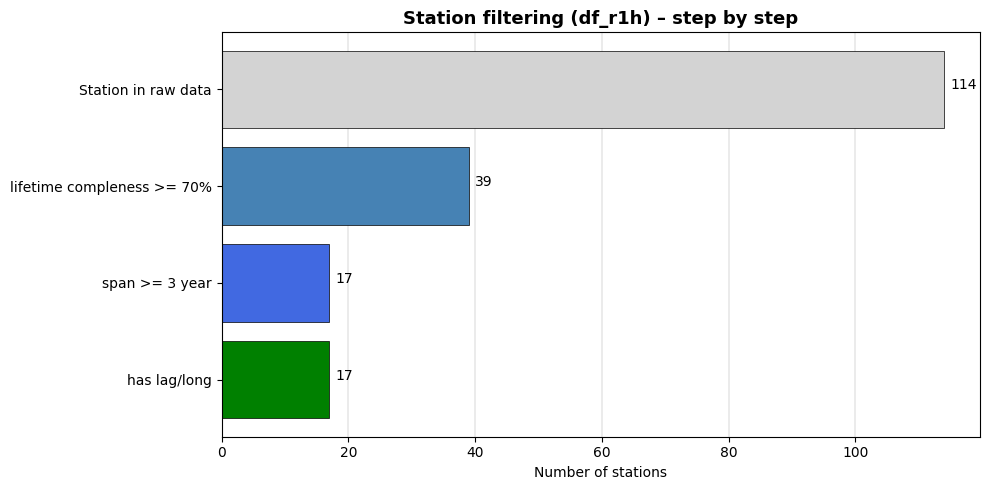

In [181]:
colors = ['green', 'royalblue', 'steelblue', 'lightgrey']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(r1h_labels, r1h_counts, color=colors, edgecolor='black', linewidth=0.5)        # ax.barh plots from bottom to top

for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(width + 1, y, str(width))

ax.set_xticks(range(0, max(r1h_counts)+1, 20))
ax.xaxis.grid(True, linewidth=0.35)
    
ax.set_title('Station filtering (df_r1h) – step by step', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of stations')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Summary DataFrame of df

In [182]:
df_summary = df.groupby('tele_station_oldcode')['rainfall_datetime'].agg(['min', 'max'])
df_summary['span_yr'] = df_summary['max'] - df_summary['min']
df_summary['span_yr'] = df_summary['span_yr'] / pd.Timedelta(365.25, 'D')
df_summary.rename(columns={'min': 'start_date','max': 'lastest_date'}, inplace=True)
df_summary['lifetime_pct'] = combined_df_pivot.mean(axis=1)

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
df_summary

,min,max
tele_station_oldcode,,
48568,2019-02-14 13:00:00,2026-04-10 01:00:00
48569,2019-02-14 13:00:00,2026-04-10 04:00:00
48571,2019-02-14 13:00:00,2026-04-10 04:00:00
48574,2019-02-14 13:00:00,2026-04-10 04:00:00
568501,2017-08-02 01:00:00,2018-11-18 19:00:00
568502,2017-08-02 01:00:00,2018-11-18 19:00:00
9999911,2017-08-02 01:00:00,2018-11-18 19:00:00
EL06,2023-05-29 16:40:00,2026-04-10 08:50:00
EL07,2023-05-29 16:40:00,2026-04-10 08:50:00


In [ ]:
# r1h_summary = df_r1h.groupby('tele_station_oldcode')['rainfall_datetime'].agg(['min', 'max'])
# r1h_summary['span_yr'] = r1h_summary['max'] - r1h_summary['min']
# r1h_summary['span_yr'] = r1h_summary['span_yr'] / pd.Timedelta(365.25, 'D')
# r1h_summary.rename(columns={'min': 'start_date','max': 'lastest_date'}, inplace=True)
# r1h_summary['lifetime_pct'] = r1h_pivot.mean(axis=1)

# r1h_summary

In [ ]:
# df_after_completeness = r1h_summary[(r1h_summary['lifetime_pct'] >= 70)]
# df_after_span = r1h_after_completeness[((r1h_after_completeness['span_yr'] >= 3))]
# df_qualified = r1h_after_span[r1h_after_span.index.isin(df_meta2['tele_station_oldcode'])]

# df_counts = [df_raw['tele_station_oldcode'].nunique(),
#              df['tele_station_oldcode'].nunique(),
             
#              ]



SyntaxError: invalid syntax (1547532986.py, line 1)